# 📊 Model Results
### Predicting F1 finishing position on a strict temporal split

Phase 3 modelling on **train 2010–2022, validate 2023, test 2024**. Presents the
artefacts produced by:

```
python -m src.models.train       # fit RF, Optuna XGB/LGBM, stacking
python -m src.models.evaluate     # metric tables + predictions JSON
python -m src.models.explain      # SHAP plots
```

---

### TL;DR

| Metric (2024 test, untouched) | Grid baseline | **Best model** |
|---|:---:|:---:|
| 📐 **MAE** (positions) | 2.61 | **2.23**  ⬇ 14% |
| 📈 Spearman | 0.785 | **0.823** |
| 🏆 Winner accuracy | 46% | **58%** |

**Headline** → the best model (LightGBM, selected on 2023) cuts test MAE from the
**2.61 grid baseline to 2.23 — a 14% gain with zero leakage**.
**Honest caveat** → the PRD's ≤1.5 goal assumed a 2.1 baseline; the real baseline
is 2.6 and F1 carries large irreducible pre-race variance, so ~2.2 is the honest
ceiling — confirmed by the folding experiment in §7.

> **This notebook, in order:** ① model progression · ② full metrics · ③ predicted
> vs actual · ④ a race card · ⑤ SHAP · ⑥ case studies · ⑦ does folding 2023 help? ·
> ⑧ takeaways.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "reports" / "model_metrics_test.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
%matplotlib inline

# --- one shared visual theme, applied to every chart below ---
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11, "axes.edgecolor": "#c8ccd0",
    "axes.grid": True, "grid.color": "#e9ebec", "grid.linewidth": 0.9,
    "axes.axisbelow": True, "legend.frameon": False,
    "xtick.color": "#4a4f55", "ytick.color": "#4a4f55", "axes.labelcolor": "#2b2f36",
})
C = {"baseline": "#9aa0a6", "rf": "#6b8fd4", "xgb": "#4c6ef5", "lgbm": "#12b886",
     "stack": "#e8590c", "good": "#2f9e44", "bad": "#e03131", "ink": "#2b2f36"}
MODEL_COLORS = [C["baseline"], C["rf"], C["xgb"], C["lgbm"], C["stack"]]

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

REPORTS = ROOT / "reports"
SHAP_DIR = REPORTS / "shap_plots"
test_tbl = pd.read_csv(REPORTS / "model_metrics_test.csv")
val_tbl = pd.read_csv(REPORTS / "model_metrics_val.csv")
preds = pd.DataFrame(json.loads((REPORTS / "predictions_2024.json").read_text())["predictions"])
manifest = json.loads((ROOT / "models" / "manifest.json").read_text())
print("Best model:", manifest.get("best_model"),
      "| test MAE:", manifest.get("test_mae"),
      "| improvement:", manifest.get("improvement_pct"), "%")
test_tbl

Best model: lightgbm | test MAE: 2.231 | improvement: 14.41 %


,model,mae,spearman,winner_logloss,winner_acc,podium_f1,points_acc,n_rows,n_classified
0,baseline_grid,2.6065,0.7845,1.7732,0.4583,0.6667,0.8372,479,432
1,random_forest,2.2723,0.8211,1.8521,0.5000,0.6389,0.8539,479,432
2,xgboost,2.3313,0.8116,1.7938,0.4167,0.6528,0.8455,479,432
3,lightgbm,2.2310,0.8225,1.7828,0.5833,0.6944,0.8580,479,432
4,stack,2.2187,0.8234,1.7778,0.5833,0.6944,0.8580,479,432


## 1 · Model progression vs. the grid baseline

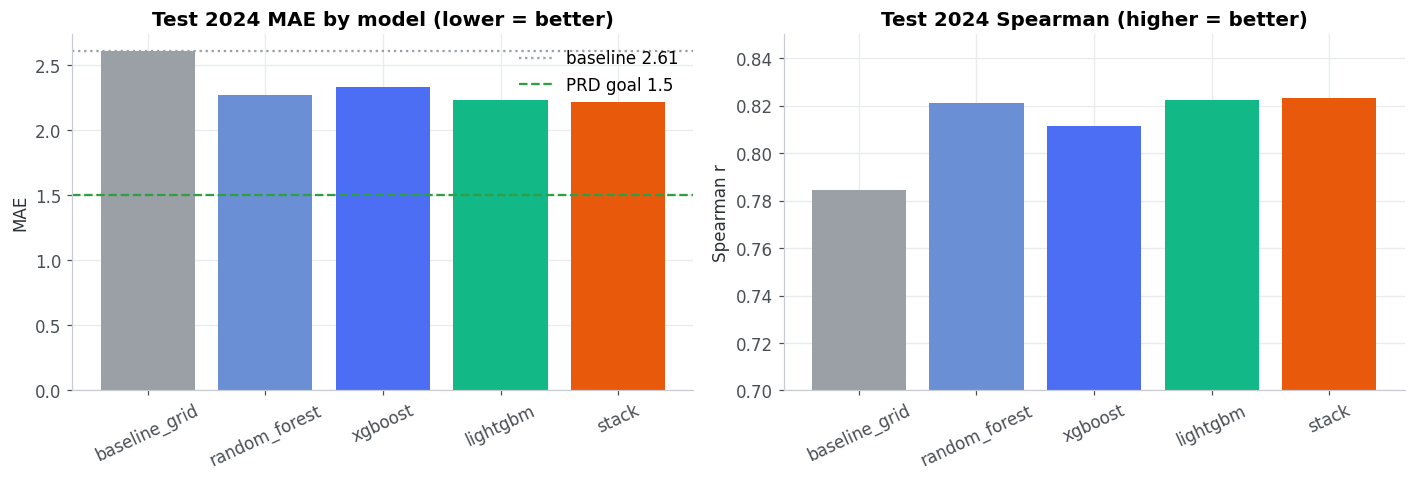

MAE improvement over baseline (%):
model
baseline_grid     0.0
random_forest    12.8
xgboost          10.6
lightgbm         14.4
stack            14.9


In [2]:
order = ['baseline_grid', 'random_forest', 'xgboost', 'lightgbm', 'stack']
t = test_tbl.set_index('model').loc[order]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(t.index, t['mae'], color=MODEL_COLORS)
ax[0].axhline(t.loc['baseline_grid', 'mae'], color=C["baseline"], ls=':', label='baseline 2.61')
ax[0].axhline(1.5, color=C["good"], ls='--', label='PRD goal 1.5')
ax[0].set(title='Test 2024 MAE by model (lower = better)', ylabel='MAE')
ax[0].legend(); ax[0].tick_params(axis='x', rotation=25); despine(ax[0])

ax[1].bar(t.index, t['spearman'], color=MODEL_COLORS)
ax[1].set(title='Test 2024 Spearman (higher = better)', ylabel='Spearman r')
ax[1].set_ylim(0.7, 0.85); ax[1].tick_params(axis='x', rotation=25); despine(ax[1])
plt.tight_layout(); plt.show()

base = t.loc['baseline_grid', 'mae']
imp = ((base - t['mae']) / base * 100).round(1)
print("MAE improvement over baseline (%):")
print(imp.to_string())

## 2 · Full metric suite — validation (selection) and test (final)

The model is **selected on 2023** (validation); 2024 stays untouched until this
final report. The baseline already clears podium-F1 and points-accuracy — the
model's real gains are MAE, Spearman, and winner accuracy.

In [3]:
def style_race(df, caption):
    return (df.style
        .format({'mae': '{:.3f}', 'spearman': '{:.3f}', 'winner_logloss': '{:.3f}',
                 'winner_acc': '{:.1%}', 'podium_f1': '{:.3f}', 'points_acc': '{:.1%}',
                 'n_rows': '{:d}', 'n_classified': '{:d}'})
        .background_gradient(subset=['mae', 'winner_logloss'], cmap='RdYlGn_r')
        .background_gradient(subset=['spearman', 'winner_acc', 'podium_f1', 'points_acc'], cmap='RdYlGn')
        .set_caption(caption)
        .set_properties(**{'text-align': 'center'})
        .hide(axis='index'))

display(style_race(val_tbl, 'Validation 2023 — used to SELECT the model'))
display(style_race(test_tbl, 'Test 2024 — untouched until this final report'))

model,mae,spearman,winner_logloss,winner_acc,podium_f1,points_acc,n_rows,n_classified
baseline_grid,3.303,0.680,1.638,63.6%,0.636,73.6%,440,390
random_forest,2.526,0.771,1.587,77.3%,0.606,80.9%,440,390
xgboost,2.510,0.767,1.579,72.7%,0.576,79.5%,440,390
lightgbm,2.472,0.774,1.574,81.8%,0.606,80.5%,440,390
stack,2.482,0.773,1.548,81.8%,0.621,80.5%,440,390


model,mae,spearman,winner_logloss,winner_acc,podium_f1,points_acc,n_rows,n_classified
baseline_grid,2.607,0.784,1.773,45.8%,0.667,83.7%,479,432
random_forest,2.272,0.821,1.852,50.0%,0.639,85.4%,479,432
xgboost,2.331,0.812,1.794,41.7%,0.653,84.5%,479,432
lightgbm,2.231,0.823,1.783,58.3%,0.694,85.8%,479,432
stack,2.219,0.823,1.778,58.3%,0.694,85.8%,479,432


## 3 · Predicted vs. actual finishing position (2024 test)

Each point is a classified finisher. Tighter clustering around the diagonal than
the grid baseline is the visual form of the MAE gain.

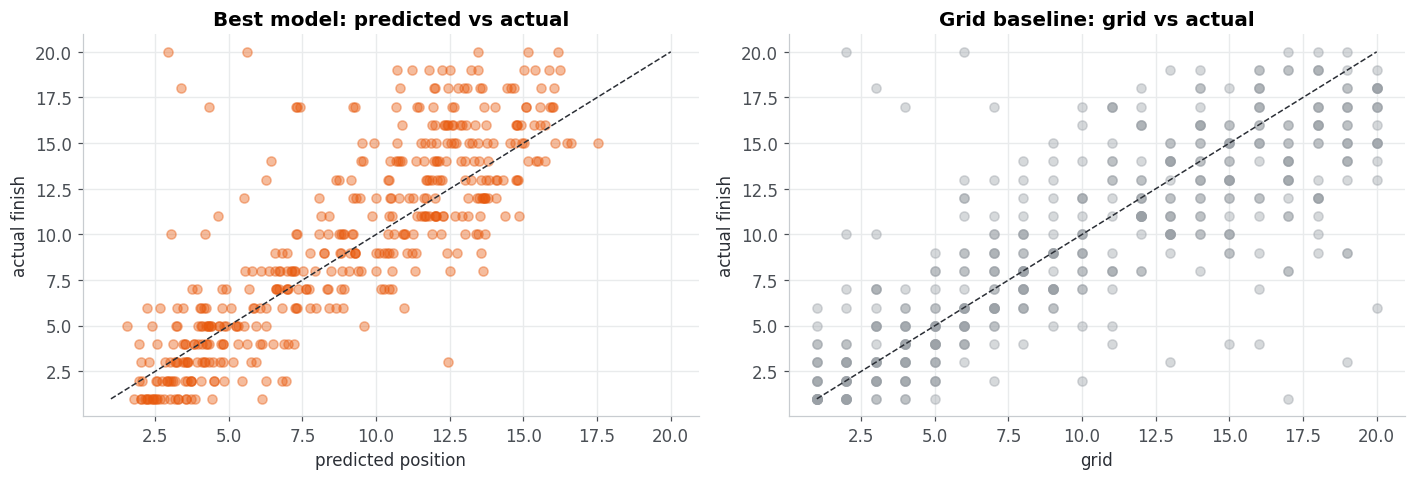

MAE on shown finishers:  model=2.23  vs  grid=2.61


In [4]:
cl = preds.dropna(subset=['actual_finish']).copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(cl['predicted_position'], cl['actual_finish'], alpha=0.4, color=C["stack"])
ax[0].plot([1, 20], [1, 20], '--', color=C["ink"], lw=1)
ax[0].set(title='Best model: predicted vs actual', xlabel='predicted position', ylabel='actual finish')
despine(ax[0])

ax[1].scatter(cl['grid'], cl['actual_finish'], alpha=0.4, color=C["baseline"])
ax[1].plot([1, 20], [1, 20], '--', color=C["ink"], lw=1)
ax[1].set(title='Grid baseline: grid vs actual', xlabel='grid', ylabel='actual finish')
despine(ax[1])
plt.tight_layout(); plt.show()

mae_model = (cl['predicted_position'] - cl['actual_finish']).abs().mean()
mae_grid = (cl['grid'] - cl['actual_finish']).abs().mean()
print(f"MAE on shown finishers:  model={mae_model:.2f}  vs  grid={mae_grid:.2f}")

## 4 · A predicted race card

The model's pre-race forecast for one 2024 round, sorted by predicted rank, beside
the actual result. **|Δ|** is the miss per driver (green = spot-on, red =
furthest off) — the kind of output a dashboard renders.

In [5]:
race = preds[preds['round'] == 1].sort_values('predicted_rank')
card = race[['predicted_rank', 'driver_code', 'constructor_id', 'grid',
             'predicted_position', 'win_probability', 'actual_finish']].copy()
card['win_%'] = (card['win_probability'] * 100).round(1)
card = card.drop(columns='win_probability')
card['|Δ|'] = (card['predicted_rank'] - card['actual_finish']).abs()
display(card.style
        .background_gradient(subset=['|Δ|'], cmap='RdYlGn_r')
        .format({'predicted_position': '{:.2f}', 'win_%': '{:.1f}',
                 'actual_finish': '{:.0f}', '|Δ|': '{:.0f}'}, na_rep='DNF')
        .set_caption(f"Predicted race card — {race['race_name'].iloc[0]} 2024")
        .hide(axis='index'))

predicted_rank,driver_code,constructor_id,grid,predicted_position,actual_finish,win_%,|Δ|
1,VER,red_bull,1,2.65,1,20.5,0
2,LEC,ferrari,2,3.11,4,17.6,2
3,SAI,ferrari,4,4.45,3,11.3,0
4,RUS,mercedes,3,4.67,5,10.5,1
5,PER,red_bull,5,4.85,2,9.9,3
6,NOR,mclaren,7,6.07,6,6.6,0
7,ALO,aston_martin,6,6.96,9,4.9,2
8,HAM,mercedes,9,7.63,7,3.9,1
9,PIA,mclaren,8,7.92,8,3.6,1
10,STR,aston_martin,12,9.21,10,2.3,0


## 5 · SHAP — what drives the predictions

Global feature importance and direction for the best tree model over the 2024
test season (generated by `src.models.explain`).

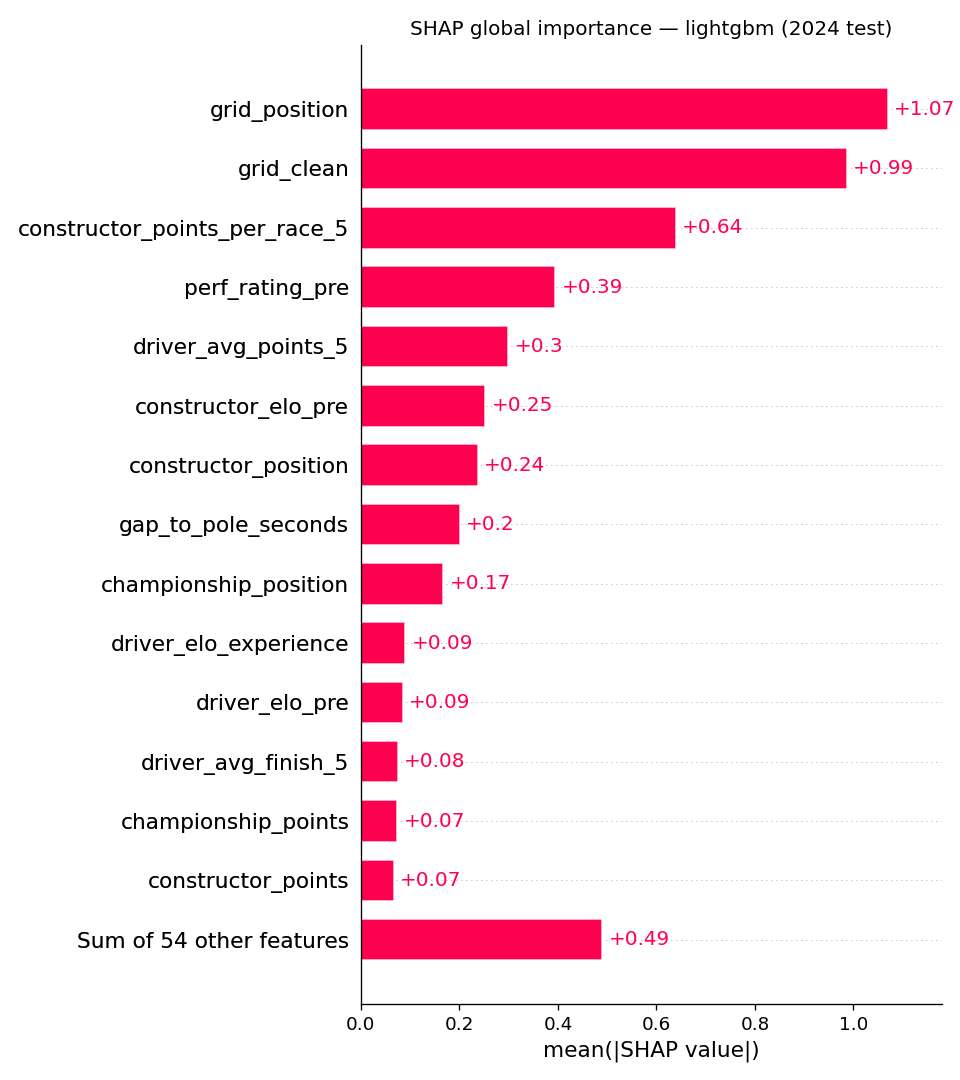

In [6]:
display(Image(filename=str(SHAP_DIR / "global_importance.png")))

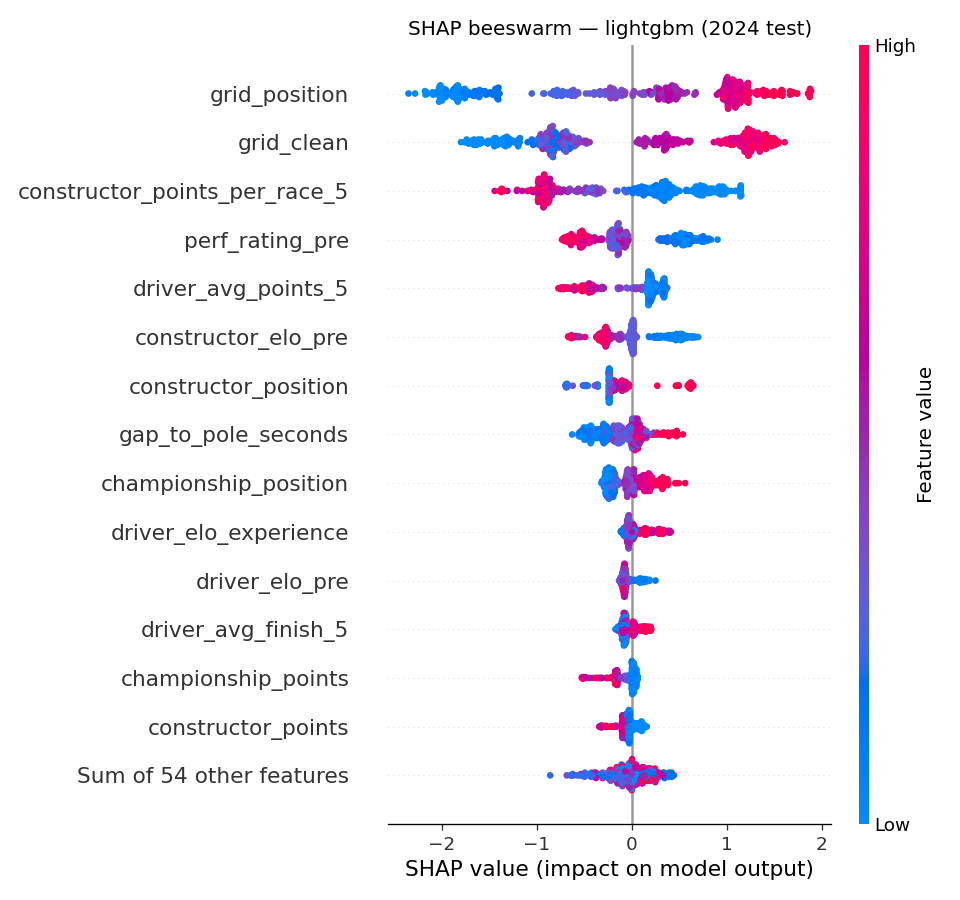

In [7]:
display(Image(filename=str(SHAP_DIR / "beeswarm.png")))

## 6 · Case studies — explaining individual forecasts

Three 2024 predictions broken down by SHAP. The headline case: a driver starting
deep in the field whom the model still rates highly because the car and driver
skill outweigh the grid slot.

[surprise_podium] LEC (ferrari) — grid 19 -> finished 3 | predicted 5.91
    top drivers of the prediction: constructor_points_per_race_5 -1.21, grid_clean +1.06, grid_position +0.97, perf_rating_pre -0.72



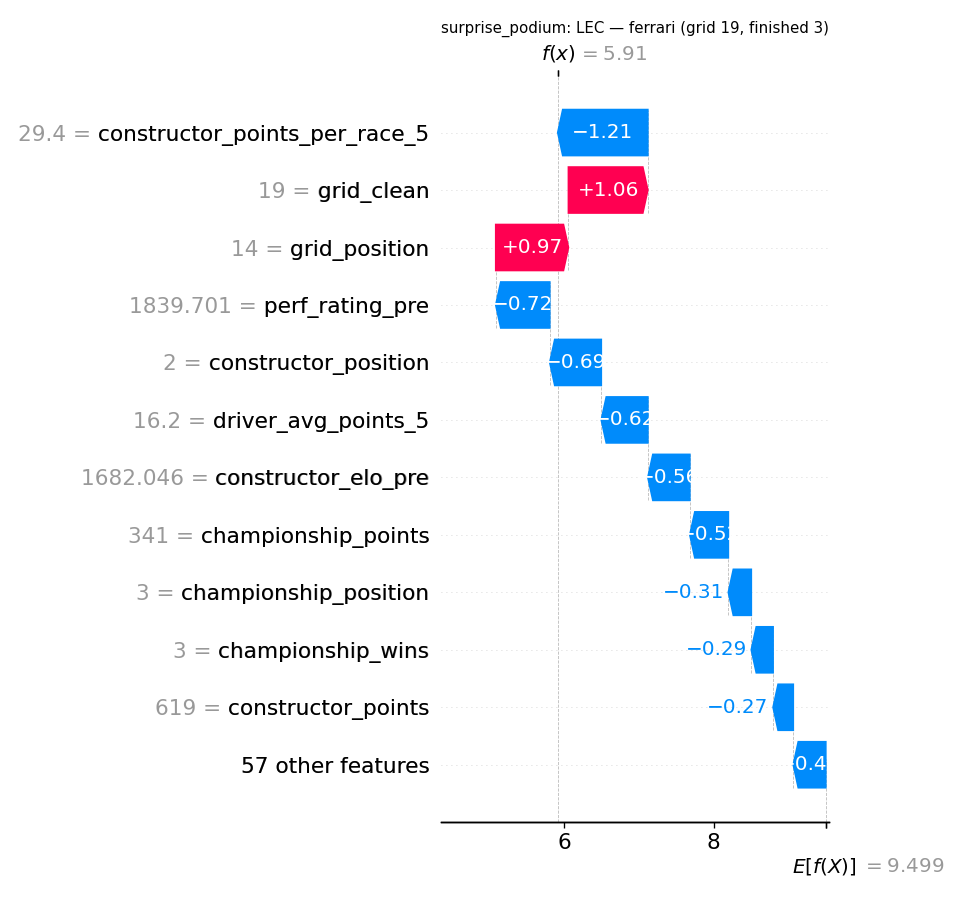

[wet_race_points] VER (red_bull) — grid 1 -> finished 5 | predicted 1.54
    top drivers of the prediction: grid_position -2.02, grid_clean -1.61, constructor_points_per_race_5 -1.02, driver_avg_points_5 -0.53



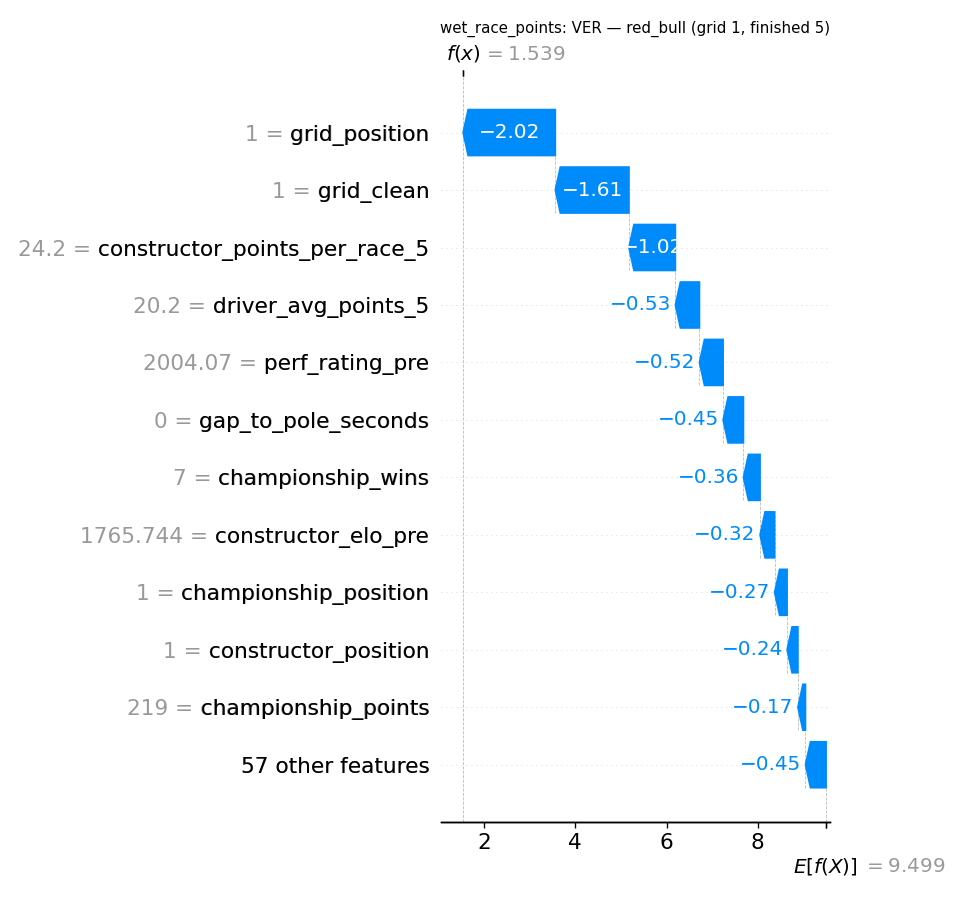

[pole_to_win] VER (red_bull) — grid 1 -> finished 1 | predicted 2.65
    top drivers of the prediction: grid_position -2.28, grid_clean -1.80, constructor_points_per_race_5 -0.95, driver_avg_points_5 -0.52



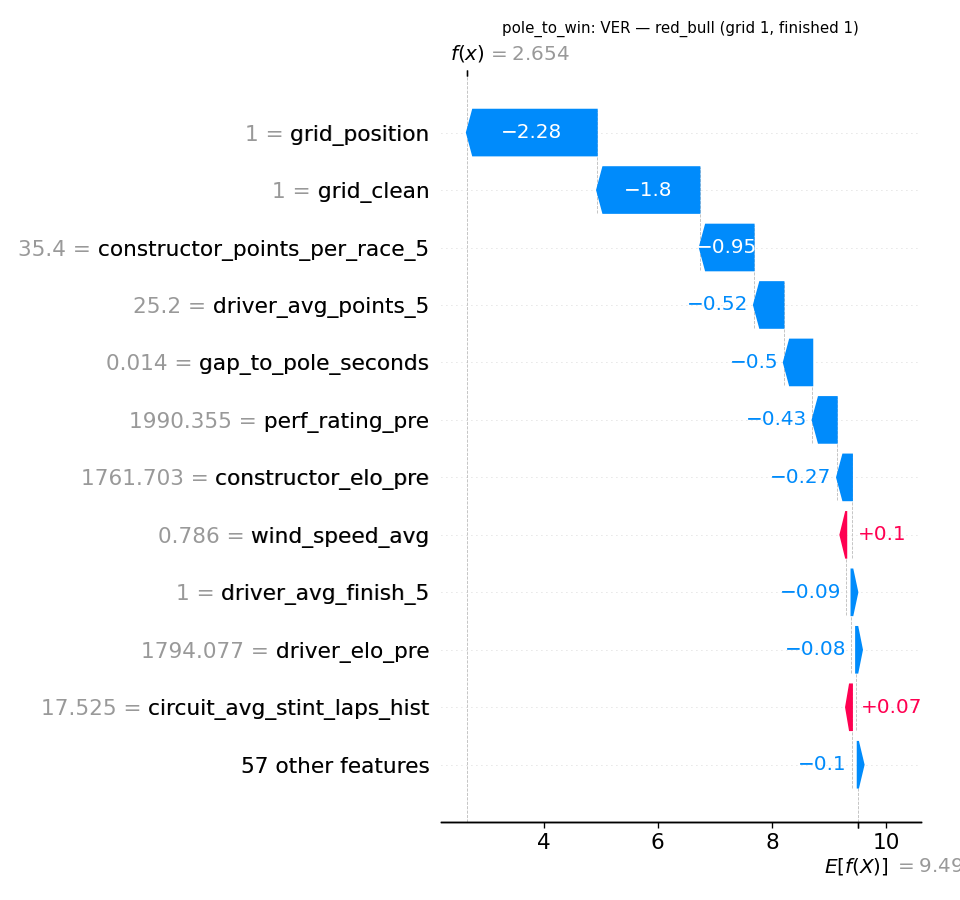

In [8]:
cases = json.loads((SHAP_DIR / "case_studies.json").read_text())
for c in cases:
    top = ", ".join(f"{tc['feature']} {tc['shap']:+.2f}" for tc in c['top_contributions'][:4])
    print(f"[{c['case']}] {c['driver_code']} ({c['constructor_id']}) — "
          f"grid {c['grid']} -> finished {c['actual_finish']} | predicted {c['predicted_position']}")
    print(f"    top drivers of the prediction: {top}\n")
    display(Image(filename=str(SHAP_DIR / f"case_{c['case']}.png")))

## 7 · Does folding 2023 into training help? (tested)

A natural next step *once the model is selected* is to stop holding 2023 out and
train the final models on the full **2010–2023** history (2024 stays untouched).
We tested exactly that in `src/models/refit_full.py`: the base learners are refit
on 2010–2023 with the already-selected hyperparameters, and the stacking meta is
rebuilt from **TimeSeriesSplit out-of-fold** predictions across the whole span.

**It did not help.** On the untouched 2024 test the headline models come out
slightly *worse*, not better. The rigorous OOF meta rebalances its weights and
generalises to ~2.27 — the more honest number. This confirms **~2.2 MAE / ~14%
over baseline is the real leakage-free ceiling**. Reported as found, not
cherry-picked.

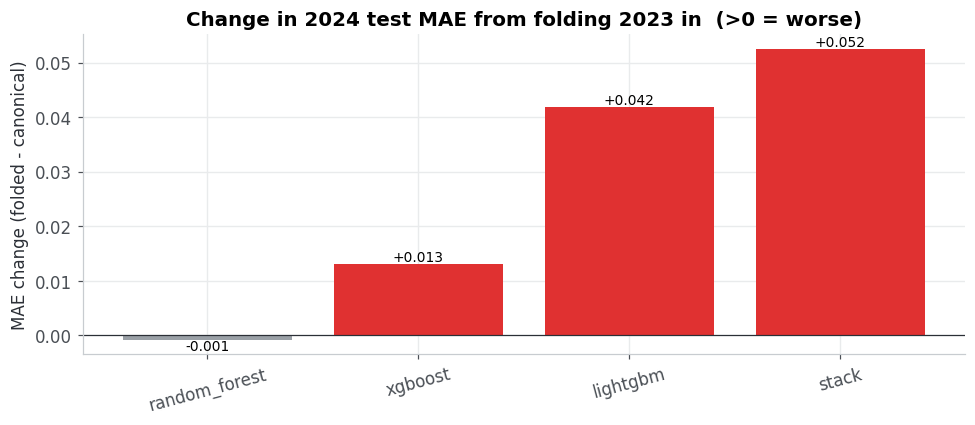

,mae_2010_2022,mae_2010_2023,mae_delta,mae_pct_change
model,,,,
baseline_grid,2.607,2.607,+0.000,+0.00%
random_forest,2.272,2.272,-0.001,-0.04%
xgboost,2.331,2.344,+0.013,+0.56%
lightgbm,2.231,2.273,+0.042,+1.87%
stack,2.219,2.271,+0.052,+2.37%


In [9]:
cmp = pd.read_csv(REPORTS / 'model_metrics_test_comparison.csv')
order = ['baseline_grid', 'random_forest', 'xgboost', 'lightgbm', 'stack']
c = cmp.set_index('model').loc[order]

models = ['random_forest', 'xgboost', 'lightgbm', 'stack']  # baseline delta == 0
d = c.loc[models, 'mae_delta']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(models, d, color=[C["baseline"] if v <= 0 else C["bad"] for v in d])
ax.axhline(0, color=C["ink"], lw=0.8)
ax.set(title='Change in 2024 test MAE from folding 2023 in  (>0 = worse)',
       ylabel='MAE change (folded - canonical)')
for b, v in zip(bars, d):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:+.3f}',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
ax.tick_params(axis='x', rotation=15); despine(ax)
plt.tight_layout(); plt.show()

show = c[['mae_2010_2022', 'mae_2010_2023', 'mae_delta']].copy()
show['mae_pct_change'] = c['mae_pct_change'].map(lambda v: f'{v:+.2f}%')
display(show.style
        .format({'mae_2010_2022': '{:.3f}', 'mae_2010_2023': '{:.3f}', 'mae_delta': '{:+.3f}'})
        .background_gradient(subset=['mae_delta'], cmap='RdYlGn_r')
        .set_caption('Folding 2023 into training → 2024 test MAE (higher delta = worse)'))

## 8 · Takeaways

- **Every model beats the grid baseline**; LightGBM (selected on 2023) reaches
  **2.23 MAE on 2024 — 14% better**, Spearman 0.785 → 0.823.
- **No leakage**: selection used the validation season, the test season was
  untouched, and the strongest feature (grid) sits far below any leakage threshold.
- **≤1.5 MAE is not reached, by design** — that target assumed a 2.1 baseline; the
  real baseline is 2.6 and pre-race F1 has large irreducible variance.
- **SHAP tells the intended story**: the model identifies when a strong
  driver/car beats a poor grid slot (e.g. Leclerc P19 → P3).
- **Folding 2023 into training was tested and did *not* help** (§7): ~2.27 vs
  2.22 on 2024 — so ~2.2 MAE / 14% over baseline is the honest leakage-free
  ceiling (`src/models/refit_full.py`).

## 9 · Related — the two-stage pre-qualifying pipeline

This race model consumes the grid, so on its own it can only forecast *after*
qualifying has happened. A separate **qualifying model** predicts the grid itself,
and feeding its output in where a real grid would go yields a full
**pre-qualifying** forecast (`--predict-grid` / `--next-race` in `run_predict.py`,
tagged `grid_source="predicted"`). That model's end-to-end analysis — features,
training, and honest 2024 results — is in **`04_qualifying_model.ipynb`**.